# OpenClassrooms - parcours Data Analyst Business Intelligence - P8

# Milestone 1 - Analyse des données

Dans cette partie nous allons analyser le jeu de données que nous avons à notre disposition. Notre objectif est de comprendre les relations entre les variables, et surtout, celles qui influent sur le prix des transactions immobilières. Grâce à ce travail, nous pourrons ne conserver que les variables qui seront utiles à l'apprentissage de notre algorithme.

## 1.Type des données

La première étape à réaliser est d'importer les données dans le notebook et d'opérer des transformations sur les variables si celles-ci s'imposent (exemple : nettoyage ou changement de type des variables, etc.).

In [55]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
#On importe les librairies que nous utiliserons pour traiter les données et les visualiser
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
# N'oubliez pas d'avoir installé les librairies pandas, numpy et matplotlib via la commande pip

In [3]:
#On importe les données dans un dataframe
df = pd.read_excel("portefeuille_actifs+(3).xlsx")
df = pd.read_excel("historique_immobilier_paris_2017_2021_vdef2.xlsx")

Attention, si l'opération ci-dessus ne marche pas, il se peut que le package "openpyxl" ne soit pas présent sur votre ordinateur. Si c'est le cas vous pouvez l'installer en éxécutant la commande : pip install openpyxl ou conda install openpyxl.

In [4]:
#On vérifie que le type des données attribué par pandas est cohérent
df.dtypes
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26196 entries, 0 to 26195
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date_mutation     26196 non-null  datetime64[ns]
 1   valeur_fonciere   26196 non-null  float64       
 2   adresse_numero    26196 non-null  int64         
 3   adresse_nom_voie  26196 non-null  object        
 4   code_postal       26196 non-null  int64         
 5   nom_commune       26196 non-null  object        
 6   code_type_local   26196 non-null  int64         
 7   type_local        26196 non-null  object        
 8   surface_reelle    26196 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(3)
memory usage: 1.8+ MB


### 2. Regardons les différents types de biens immobiliers que nous avons dans nos données :

In [5]:
print('la liste des différents types de biens immobiliers que nous avons dans les données est ?:')
print(df["type_local"].unique())
print(df["code_type_local"].unique())


la liste des différents types de biens immobiliers que nous avons dans les données est ?:
['Appartement' 'Local industriel. commercial ou assimilé']
[2 4]


On observe qu'il y a ? types de biens, et que leurs codes types sont ?. 

### 3. Nombre de transactions

In [6]:
#On verifie le nombre de transactions que nous avons dans notre dataframe
print('le nombre de transactions dans les données est' ,len(df))
print('le nombre de transactions pour les appartements dans les données est' ,(df["type_local"] == "Appartement").sum())
print('le nombre de transactions pour les locaux commerciaux dans les données est' , (df["type_local"] == "Local industriel. commercial ou assimilé").sum())

le nombre de transactions dans les données est 26196
le nombre de transactions pour les appartements dans les données est 24353
le nombre de transactions pour les locaux commerciaux dans les données est 1843


### 4. interval de l'historique des données

In [7]:
#On vérifie également la plage de l'historique disponible
print('la première date de transaction dans les données est le ?')
print(df['date_mutation'].min())

print('la dernière date de transaction dans les données est le ?')
print(df['date_mutation'].max())

la première date de transaction dans les données est le ?
2017-01-02 00:00:00
la dernière date de transaction dans les données est le ?
2021-12-31 00:00:00


## Commençons à analyser les données

Maintenant nous allons analyser les données historiques pour les 2 différents types de biens immobiliers en essayant d'identifier les relations entre les variables. Mais avant cela, il nous faudra pouvoir comparer les biens entre eux, et pour cela nous allons créer une colonne du prix au metre carré.

In [8]:
# Calcul de la colonne
df['prix_m2'] = df['valeur_fonciere'] / df['surface_reelle']
df[['valeur_fonciere', 'surface_reelle', 'prix_m2']].head()

,valeur_fonciere,surface_reelle,prix_m2
0,5.505597e+05,50,11011.193562
1,1.576492e+06,163,9671.732877
2,6.577574e+05,66,9966.020548
3,2.500868e+05,22,11367.582877
4,1.762667e+05,15,11751.113836


Maintenant, analysons les appartements.

### 5. Evolution du prix au metre carré des appartements dans Paris

In [9]:
#On retire les colonnes qui sont à priori inutiles ET nous allons nous concentrer sur les appartements dans un premier temps
df_appart = df[df['type_local'] == 'Appartement'].copy()

In [10]:
#Préparons un dataframe en regroupant les prix moyens de ventes des appartements par année avec la surface moyenne associée
# Création de la colonne année à partir de la date de mutation
df_appart['annee'] = df_appart['date_mutation'].dt.year

# Regroupement par année
df_annee = (
    df_appart
    .groupby('annee')
    .agg(
        prix_m2_moyen=('prix_m2', 'mean'),
        surface_moyenne=('surface_reelle', 'mean')
        
    )
    .reset_index()
)

In [11]:
# Regroupement par année
df_annee = (
    df_appart
    .groupby('annee')
    .agg(
        prix_m2_moyen=('prix_m2', 'mean'),
        surface_moyenne=('surface_reelle', 'mean')
    )
    .reset_index()
)
df_annee.head()

,annee,prix_m2_moyen,surface_moyenne
0,2017,9492.859195,44.627737
1,2018,10031.403432,44.271671
2,2019,10562.712581,43.361645
3,2020,10674.872650,42.900654
4,2021,10455.600126,43.479864


On constate sur la moyenne des prix de vente des appartements à Paris que ? <br>
Nous allons créer un graphique pour mieux le visualiser.

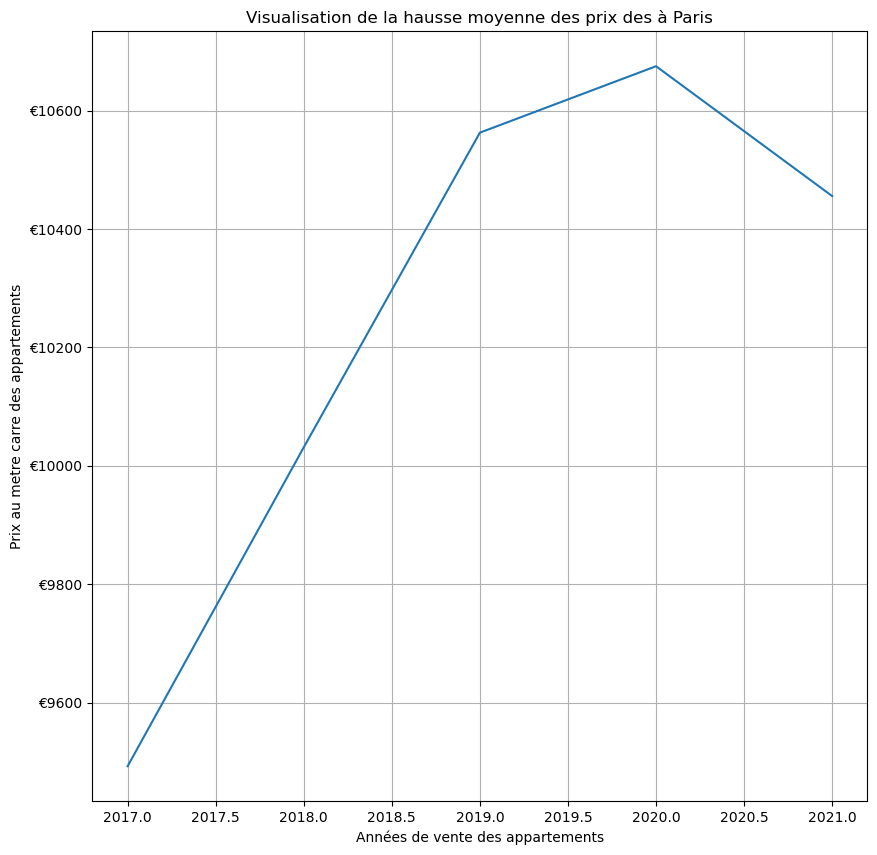

In [12]:
#Création d'un graphique pour visualiser la hausse de la moyenne des prix
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
plt.figure(figsize=(10,10))
plt.plot(df_annee['annee'], df_annee['prix_m2_moyen'],)
plt.xlabel('Années de vente des appartements')
plt.ylabel('Prix au metre carre des appartements')
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid()
plt.title('Visualisation de la hausse moyenne des prix des à Paris')
plt.show()

### 6. Différences de prix au metre carré entre les arrondissements

Maintenant nous allons chercher à afficher l'évolution des prix par arrondissement. Vérifions la liste des arrondissements que nous avons dans nos données. Normalement à Paris nous avons 20 codes postaux différents, 1 par arrondissement allant de 75001 à 75020.

In [13]:
#Liste des codes postaux dans nos données.
codes_postaux = (df_appart['code_postal'].dropna().astype(int).sort_values().unique())
print("Codes postaux présents dans les données :")
print(codes_postaux)


Codes postaux présents dans les données :
[75001 75002 75003 75004 75005 75006 75007 75008 75009 75010 75011 75012
 75013 75014 75015 75016 75017 75018 75019 75020]


In [14]:
#Créeons un dataframe pour une deuxième visualisation avec l'evolution des prix par arrondissement
df_arrondissement = (
    df_appart
    .groupby(['annee', 'code_postal'])
    .agg(
        prix_m2_moyen=('prix_m2', 'mean'),
        nb_ventes=('prix_m2', 'count')
    )
    .reset_index()
    .sort_values(['annee', 'code_postal'])
)
df_arrondissement.head()

,annee,code_postal,prix_m2_moyen,nb_ventes
0,2017,75001,11762.706289,87
1,2017,75002,10920.126562,129
2,2017,75003,11679.818729,171
3,2017,75004,12407.227522,108
4,2017,75005,11306.752404,208


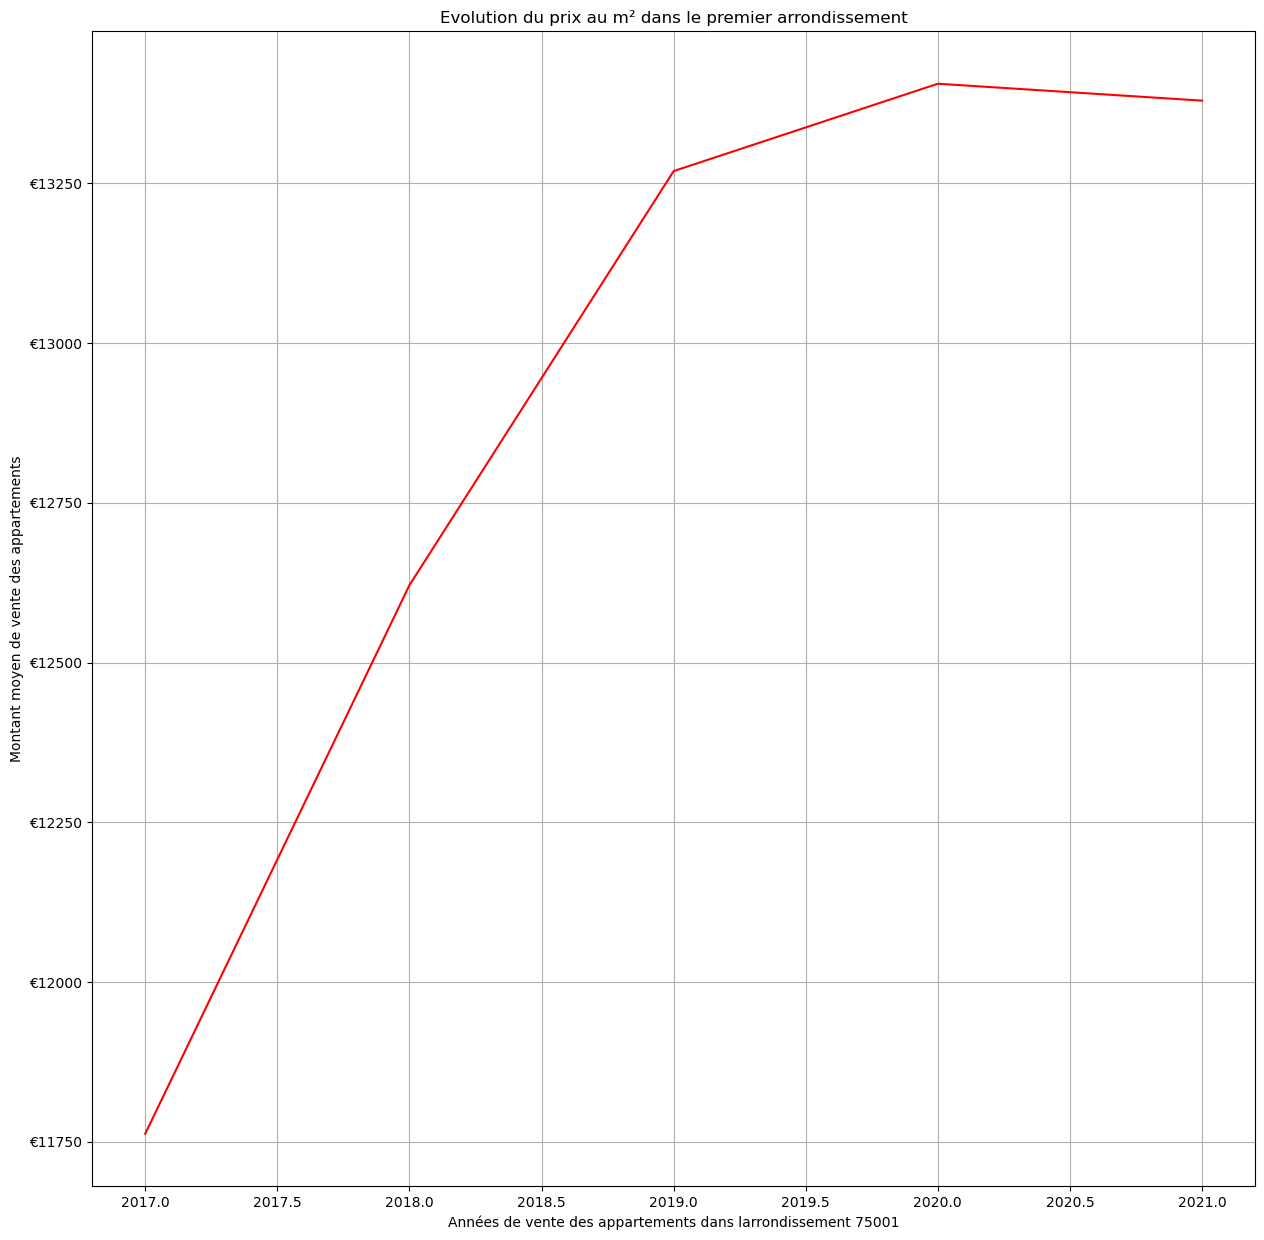

In [15]:
#Création d'un graphique pour visualiser la hausse de la moyenne des prix au metre carré dans le premier arrondissement
plt.figure(figsize=(15,15))

# Filtrer les données pour le premier arrondissement (75001)
data_75001 = df_arrondissement[df_arrondissement['code_postal'] == 75001]

# Tracer la ligne avec les données : x = années, y = prix_m2_moyen
plt.plot(data_75001['annee'], data_75001['prix_m2_moyen'], color='red')
plt.xlabel('Années de vente des appartements dans larrondissement 75001')
plt.ylabel('Montant moyen de vente des appartements')
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid()
plt.title('Evolution du prix au m² dans le premier arrondissement')
plt.show()

Nous allons ajouter à cette visualisation tous les autres arrondissement avec une couleur différente.

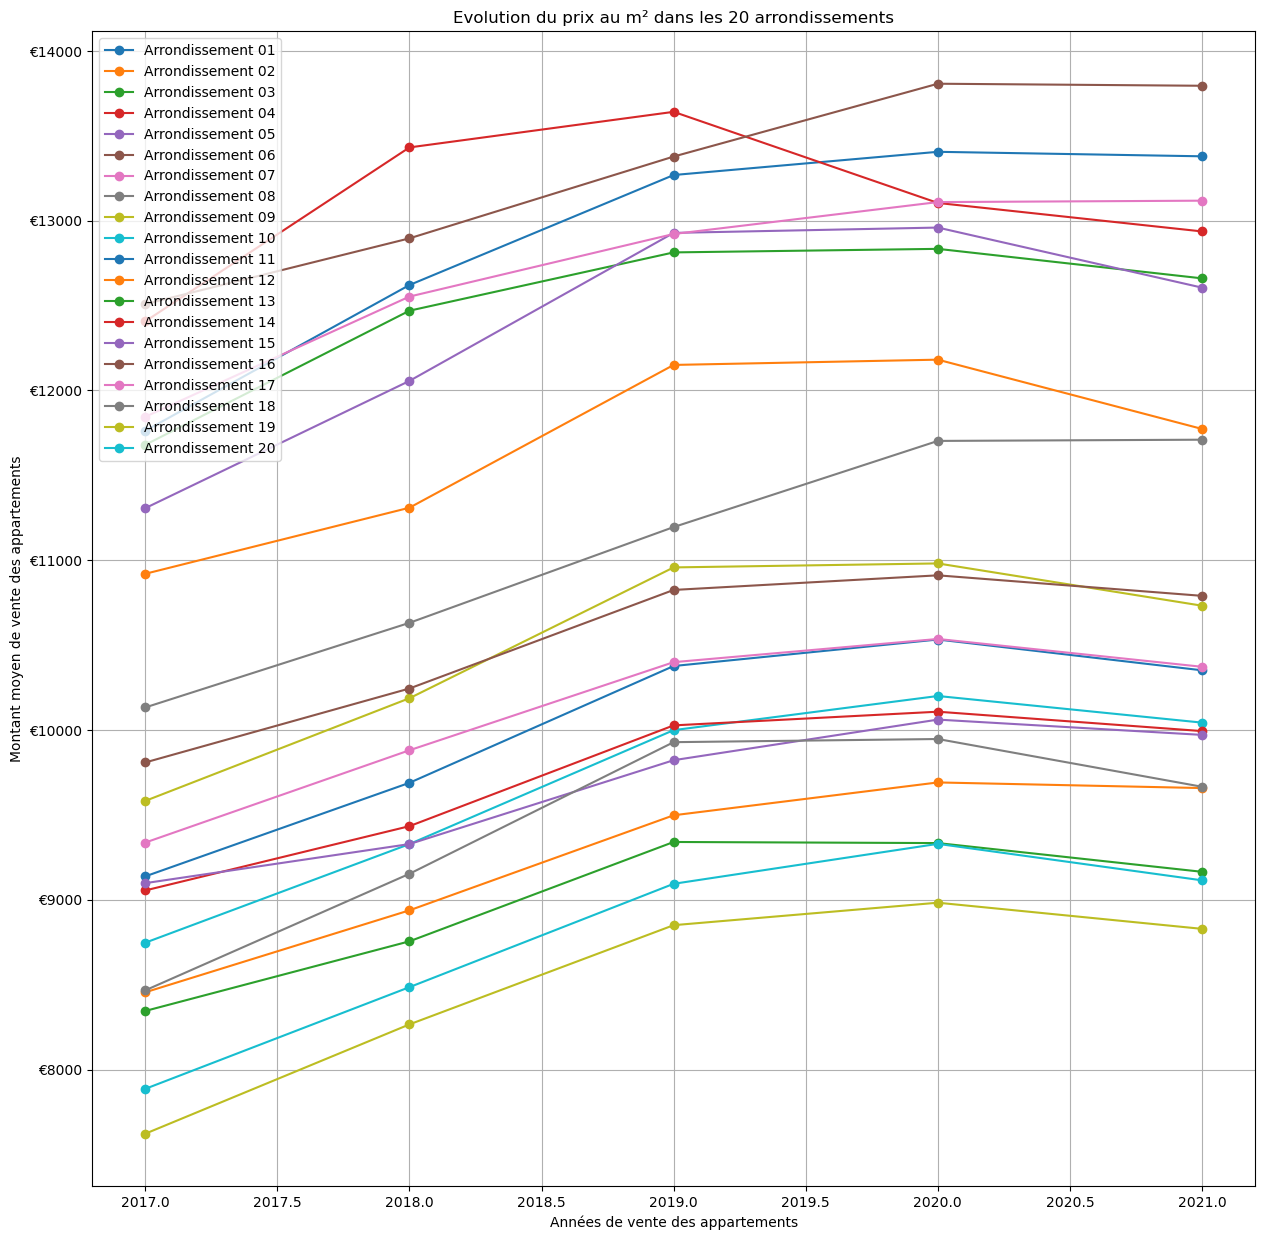

In [16]:
#On affiche l'évolution du prix au m² par arrondissement dans Paris
plt.figure(figsize=(15,15))
interval_historique=['2017','2018','2019','2020','2021']
#Insérer les lignes à tracer ci-dessous
# On boucle sur chaque code postal unique (arrondissement) pour tracer une ligne par arrondissement
for code in df_arrondissement['code_postal'].unique():
    # Filtrer les données pour cet arrondissement
    data = df_arrondissement[df_arrondissement['code_postal'] == code]
    # Tracer la ligne : x = années, y = prix_m2_moyen
    # Utiliser une couleur différente pour chaque arrondissement (via un cycle automatique)
    plt.plot(data['annee'], data['prix_m2_moyen'], label=f'Arrondissement {str(code)[-2:]}', marker='o')



plt.xlabel('Années de vente des appartements')
plt.ylabel('Montant moyen de vente des appartements')
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid()
plt.title('Evolution du prix au m² dans les 20 arrondissements')
plt.legend(loc='upper left')
plt.show()

On observe que globalement que ?

### 7. Prix au metre carré par transaction dans un arrondissement

In [17]:
#Vérifions le nombre de transaction dans le 6ème car le prix semble élevé
df_arrondissement = (
    df_appart
    .groupby(['annee', 'code_postal'])
    .agg(
        prix_m2_moyen=('prix_m2', 'mean'),
        nb_transactions=('prix_m2', 'count')
    )
    .reset_index()
)


df_arrondissement[df_arrondissement['code_postal'] == 75006][
    ['annee', 'prix_m2_moyen', 'nb_transactions']
]



,annee,prix_m2_moyen,nb_transactions
5,2017,12508.837036,198
25,2018,12896.276640,175
45,2019,13378.073631,123
65,2020,13807.087614,108
85,2021,13795.048958,105


On constate que ?

Affichons l'historique des transactions pour visualiser la dispersion des données :

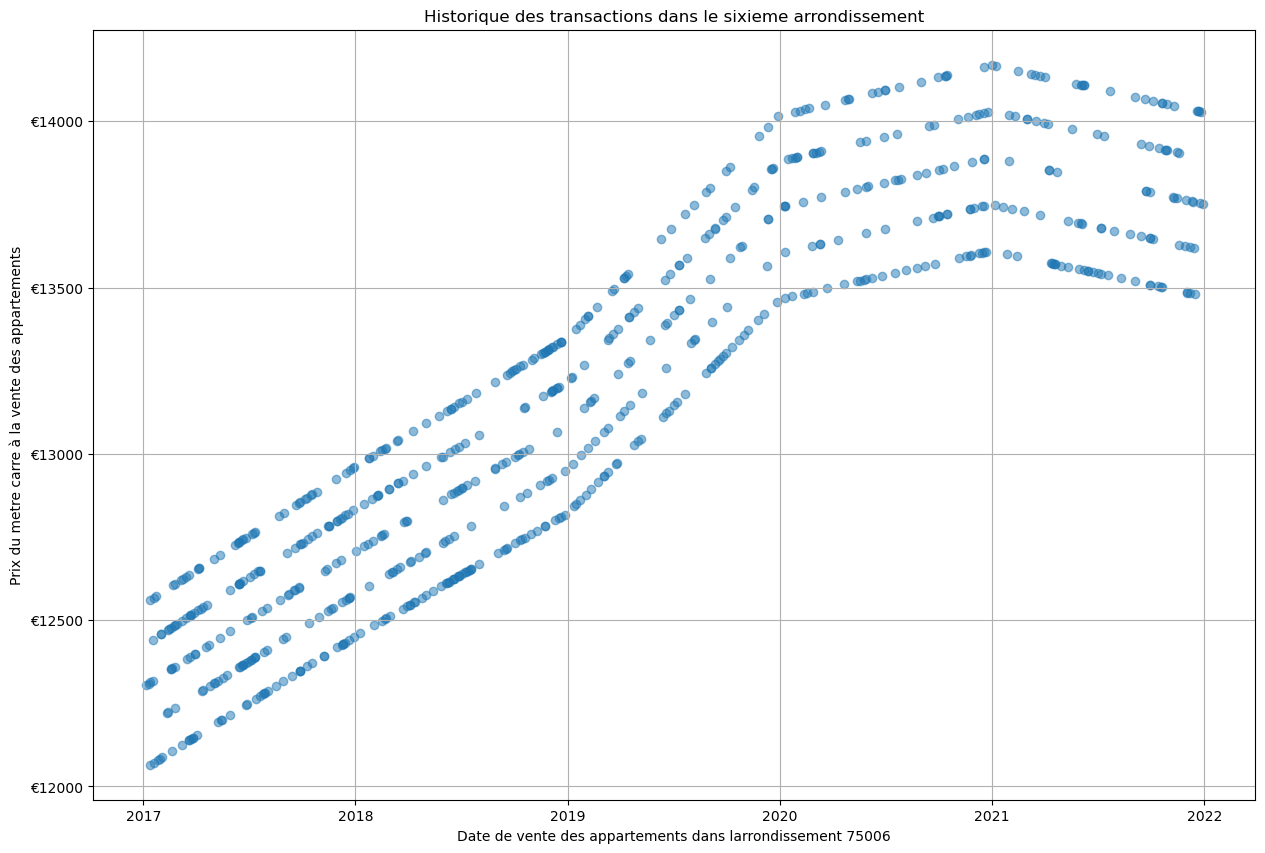

In [18]:
cp=75006
plt.figure(figsize=(15,10))
#Insérer ci-dessous le scatter plot
# Filtrer les données pour le 6e arrondissement
data_75006 = df_appart[df_appart['code_postal'] == cp]
plt.scatter(                                   #Scatter plot = idéal pour repérer outliers et variabilité
    data_75006['date_mutation'],
    data_75006['prix_m2'],
    alpha=0.5                                #alpha=0.5 → visualise mieux la dispersion
)


plt.xlabel('Date de vente des appartements dans larrondissement 75006')
plt.ylabel('Prix du metre carre à la vente des appartements')
formatter = ticker.FormatStrFormatter('€%.0f')
plt.gca().yaxis.set_major_formatter(formatter)

plt.grid(which='both')
plt.title('Historique des transactions dans le sixieme arrondissement')
plt.show()

On observe que ?

Pour nous rassurer sur la relation entre les données nous allons utiliser un test statistique de corrélation.

### 8. Vérification de la relation entre le prix au m² et la date dans le 6ème arrondissement par le calcul du coefficient de corrélation de Pearson 

Pour cette distribution nous allons calculer le coefficient de corrélation de Pearson. La relation entre le prix au metre carré et la date n'est pas forcément linéaire mais elle s'en rapproche suffisamment pour que cette analyse soit pertinente (voir l'évolution du prix au metre carré globale montrée plus haut, on a presque une droite sauf entre 2020 et 2021). Ce qui nous interesse c'est de prouver que le temps a une influence sur le prix.

In [19]:
#On calcule la corrélation de Spearman
from scipy import stats
# Filtrer le 6e arrondissement
data_75006 = df_appart[df_appart['code_postal'] == 75006].copy()

# Conversion de la date en valeur numérique
data_75006['date_num'] = data_75006['date_mutation'].astype('int64')
# Calcul du coefficient de Spearman
coef_s, p_value_s = stats.spearmanr(
    data_75006['date_num'],
    data_75006['prix_m2']
)

coef_s, p_value_s



(np.float64(0.914844977318667), np.float64(1.1999820574654143e-280))

Le coefficient de corrélation est de ? avec une pvalue de ? donc nous pouvons confirmer la corrélation.

In [20]:
#nous constatons que 
#ρ ≈ +1 → forte relation croissante
#plus la date est récente, plus le prix au m² est élevé
#p-value < 0.01 → relation non significative
#Le coefficient de corrélation de Spearman met en évidence une relation monotone positive et statistiquement très significative entre 
#la date de mutation et le prix au mètre carré dans le 6ᵉ arrondissement.

### 9. Vérification de la relation entre la valeur fonciere et la surface

In [21]:
#On calcule la corrélation de Spearman
from scipy import stats
# Filtrer le 6e arrondissement
data_75006 = df_appart[df_appart['code_postal'] == 75006].copy()

# Calcul du coefficient de Spearman
coef_s, p_value_s = stats.spearmanr(
    data_75006['valeur_fonciere'],
    data_75006['surface_reelle']
)

coef_s, p_value_s

(np.float64(0.9977685406899678), np.float64(0.0))

Le coefficient de corrélation est de ? avec une pvalue de ?. La relation est donc confirmée.

In [22]:
#nous constatons que 
#ρ ≈ +1 → forte relation croissante
#plus la surface est elevée, plus la valeur foncière est élevée
#p-value=0 → preuve statistique très forte
#Le coefficient de corrélation de Spearman met en évidence une relation monotone positive et statistiquement prouvée très forte entre 
#la surface et valeur foncière dans le 6ᵉ arrondissement.

Regardons maintenant si le type de bien à une influence sur le prix au metre carré également.

### 10. Analyse des locaux industriels, commerciaux et assimilés 

In [23]:
#On crée un dataset qui ne contient que les locaux commerciaux
# Filtrer uniquement les locaux commerciaux
df_locaux_commerciaux = df[df['type_local'] == 'Local industriel. commercial ou assimilé'].copy()
df_locaux_commerciaux.shape
df_locaux_commerciaux.head(5)

,date_mutation,valeur_fonciere,adresse_numero,adresse_nom_voie,code_postal,nom_commune,code_type_local,type_local,surface_reelle,prix_m2
18,2017-02-01,3.113277e+06,65,RUE DE TURBIGO,75003,Paris 3e Arrondissement,4,Local industriel. commercial ou assimilé,250,12453.109192
29,2017-02-17,1.164375e+06,17,RUE DU PONT AUX CHOUX,75003,Paris 3e Arrondissement,4,Local industriel. commercial ou assimilé,95,12256.581685
34,2017-02-20,3.802522e+05,10,RUE CAFFARELLI,75003,Paris 3e Arrondissement,4,Local industriel. commercial ou assimilé,31,12266.199603
91,2017-03-09,3.623842e+05,33,RUE DE RICHELIEU,75001,Paris 1er Arrondissement,4,Local industriel. commercial ou assimilé,29,12496.006027
109,2017-03-29,3.159072e+05,130,RUE VIEILLE DU TEMPLE,75003,Paris 3e Arrondissement,4,Local industriel. commercial ou assimilé,25,12636.289027


In [24]:
#Préparons un dataframe en regroupant les prix au metre carré moyens des ventes par année
import pandas as pd

# Filtrage : ne garder que les locaux commerciaux
df_locaux_commerciaux = df[df['type_local'] == 'Local industriel. commercial ou assimilé'].copy()

# Vérifier que la date est bien en datetime
df_locaux_commerciaux['date_mutation'] = pd.to_datetime(df_locaux_commerciaux['date_mutation'])

# Créer une colonne "année"
df_locaux_commerciaux['annee'] = df_locaux_commerciaux['date_mutation'].dt.year

# Calculer le prix au m²
df_locaux_commerciaux['prix_m2'] = (
    df_locaux_commerciaux['valeur_fonciere'] / df_locaux_commerciaux['surface_reelle']
)

# Regrouper par année et calculer le prix moyen au m²
df_annee_locaux = (
    df_locaux_commerciaux
    .groupby('annee')
    .agg(prix_m2_moyen=('prix_m2', 'mean'))
    .reset_index()
)

# Vérification
print(df_annee_locaux)



   annee  prix_m2_moyen
0   2017   10949.909217
1   2018   11569.499180
2   2019   11960.132050
3   2020   11966.470204
4   2021   12006.488691


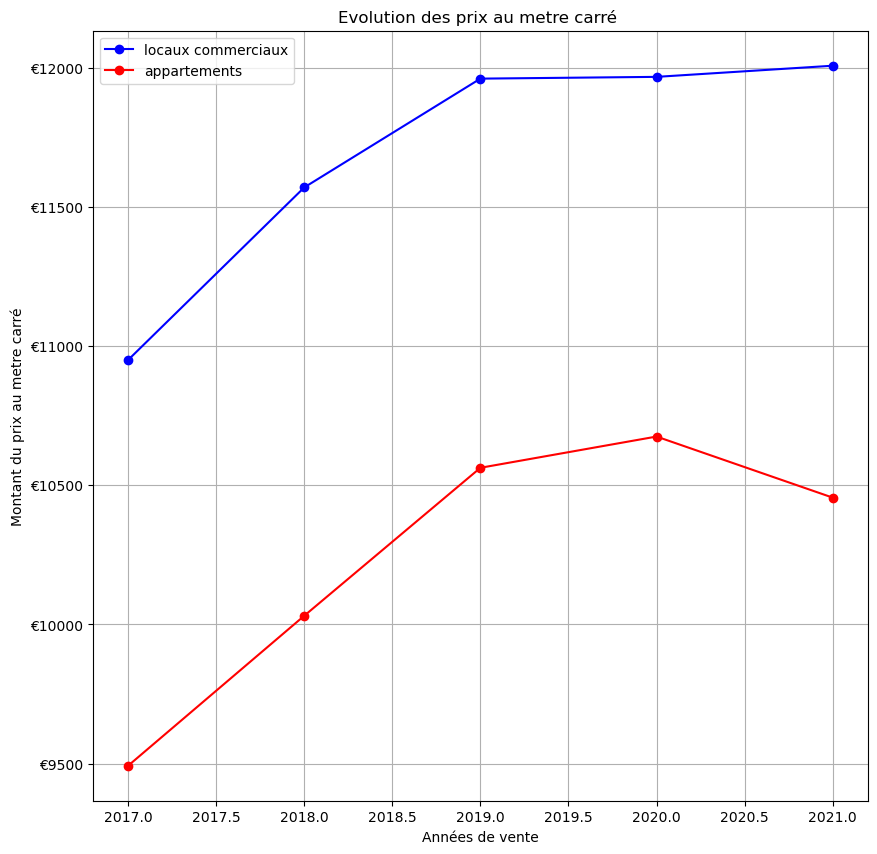

In [25]:
#Création d'un graphique pour visualiser la hausse de la moyenne des prix
plt.figure(figsize=(10,10))
# Tracer l'évolution des prix moyens pour les locaux commerciaux
plt.plot(df_annee_locaux['annee'],df_annee_locaux['prix_m2_moyen'],label='locaux commerciaux',color='blue', marker='o')
# Tracer l'évolution des prix moyens pour les appartements

#On crée unee colonne 'prix_m2_moyen'.
df_annee = df_appart.groupby('annee').agg(prix_m2_moyen=('prix_m2', 'mean')).reset_index()

plt.plot(df_annee['annee'],df_annee['prix_m2_moyen'],label='appartements',color='red', marker='o')
plt.xlabel('Années de vente')
plt.ylabel('Montant du prix au metre carré')
plt.legend()
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid()
plt.title('Evolution des prix au metre carré ')
plt.show()

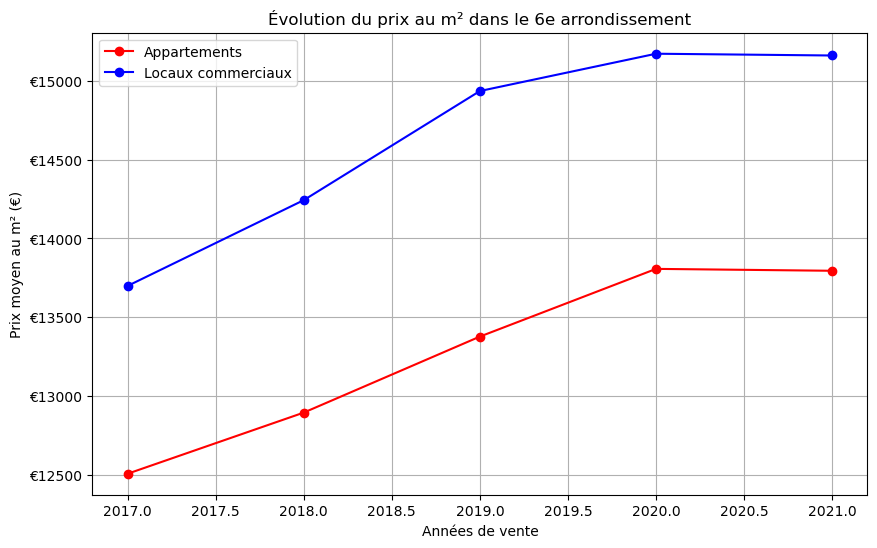

In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

cp = 75006

# --- Filtrer les appartements dans le 6e arrondissement ---
df_6e_apparts = df_appart[df_appart['code_postal'] == cp].copy()
df_6e_apparts['date_mutation'] = pd.to_datetime(df_6e_apparts['date_mutation'])
df_6e_apparts['annee'] = df_6e_apparts['date_mutation'].dt.year
df_6e_apparts['prix_m2'] = df_6e_apparts['valeur_fonciere'] / df_6e_apparts['surface_reelle']
df_annee_apparts_6e = df_6e_apparts.groupby('annee').agg(
    prix_m2_moyen=('prix_m2', 'mean')
).reset_index()

# --- Filtrer les locaux commerciaux dans le 6e arrondissement ---
df_6e_locaux = df_locaux_commerciaux[df_locaux_commerciaux['code_postal'] == cp].copy()
df_6e_locaux['date_mutation'] = pd.to_datetime(df_6e_locaux['date_mutation'])
df_6e_locaux['annee'] = df_6e_locaux['date_mutation'].dt.year
df_6e_locaux['prix_m2'] = df_6e_locaux['valeur_fonciere'] / df_6e_locaux['surface_reelle']
df_annee_locaux_6e = df_6e_locaux.groupby('annee').agg(
    prix_m2_moyen=('prix_m2', 'mean')
).reset_index()

# --- Graphique ---
plt.figure(figsize=(10,6))

plt.plot(
    df_annee_apparts_6e['annee'],
    df_annee_apparts_6e['prix_m2_moyen'],
    label='Appartements',
    color='red',
    marker='o'
)

plt.plot(
    df_annee_locaux_6e['annee'],
    df_annee_locaux_6e['prix_m2_moyen'],
    label='Locaux commerciaux',
    color='blue',
    marker='o'
)

plt.xlabel('Années de vente')
plt.ylabel('Prix moyen au m² (€)')
plt.title('Évolution du prix au m² dans le 6e arrondissement')
plt.legend()

formatter = ticker.FormatStrFormatter('€%.0f')
plt.gca().yaxis.set_major_formatter(formatter)

plt.grid(True)
plt.show()


Le prix au metre carré des locaux commerciaux est ?

Après ces analyses, nous pouvons conclure que les dimensions à utiliser pour prédire le prix au m² sont : 
- la surface du bien immobilier,
- la date considérée, 
- la localisation (code_postal), 
- le type de bien.

# Milestone 2 - Entraînement de l'algorithme

Dans cette section nous allons maintenant entrâiner un algorithme à prédire la valeur fonciere d'un bien immobilier. Pour cela nous allons utiliser l'algorithme de régression linéaire.

On commence par préparer nos données en transformant les colonnes catégoriques du code postal et du type de local grâce au one hot encoder (sklearn) / get_dummies (pandas)

In [27]:
#Certaines colonnes de notre jeu de données sont catégoriques, notamment :
#*Code postal
#*Type de local (Appartement,Local commercial..)
#Ces colonnes contiennent du texte ou des catégories, ce qui les rend incompatibles directement avec la régression linéaire.
#Solution : One-Hot Encoding
#Nous utilisons le One-Hot Encoding, qui consiste à :
#*créer une colonne par catégorie
#*remplir ces colonnes avec des valeurs 0 ou 1
#*éviter toute notion d’ordre artificiel entre les catégories
#Deux outils peuvent être utilisés :
#get_dummies() de pandas
#OneHotEncoder de scikit-learn

In [28]:
#Encodage avec Pandas (get_dummies)
#C’est la méthode la plus simple et la plus lisible.

import pandas as pd

# Encodage des variables catégoriques
df_encoded = pd.get_dummies(
    df,
    columns=["code_postal", "type_local"],
    drop_first=True
)


#columns : colonnes à encoder
#drop_first=True :
#supprime une catégorie de référence
#évite la multicolinéarité (important en régression linéaire)


In [59]:
#Encodage avec Scikit-learn (OneHotEncoder)
#Cette méthode est plus robuste et recommandée dans un pipeline de machine learning.

from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore"
)
encoded_features = encoder.fit_transform(
    df[["code_postal", "type_local"]]
)
# On s'assure que les index sont alignés
df = df.reset_index(drop=True)

#Puis on recrée un DataFrame :
encoded_df = pd.DataFrame(
    encoded_features,
    columns=encoder.get_feature_names_out()
)
df_final = pd.concat(
    [df.drop(["code_postal", "type_local"], axis=1), encoded_df],
    axis=1)

#Cette étape Permet à la régression linéaire de fonctionner
#✔ Évite de fausses relations numériques
#✔ Améliore la qualité des prédictions
#✔ Rend le modèle interprétable


#Explications:
#drop="first"
#Supprime une catégorie par variable
#Évite la multicolinéarité en régression linéaire

#sparse_output=False
#Demande un tableau dense (et non une matrice creuse)
#Plus simple à convertir en DataFrame pandas
#Sans ça, on obtiendra un objet difficile à manipuler

#handle_unknown="ignore"
#Empêche une erreur si une nouvelle catégorie apparaît
#Exemple :
#nouveau code postal jamais vu à l’entraînement
#Le modèle mettra simplement 0 partout

#fit_transform retourne un tableau NumPy
#On veut un DataFrame pandas pour :
#lire les colonnes
#fusionner les données

#get_feature_names_out()
#Donne les noms exacts des nouvelles colonnes
#Exemple :
#code_postal_75002
#type_local_Appartement

#df.drop(...)
#Supprime les anciennes colonnes textuelles, elles ne sont plus utiles

# pd.concat(..., axis=1)
#Ajoute les nouvelles colonnes encodées
#Horizontalement (colonne par colonne)

# Résultat final :
#un DataFrame 100 % numérique prêt pour :
#train / test split
#régression linéairetype_local_Appartement



On utilise le train_test_split pour prélever un tiers de nos données (33%) et les garder de côté. Nous allons entraîner notre algorithme sur le reste des données et puis mesurer notre erreur moyenne en pourcentage de la valeur foncière

In [60]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error


# On s'assure que les catégories sont des chaînes de caractères AVANT l'encodage
cols_cat = ["code_postal", "type_local"]
df[cols_cat] = df[cols_cat].astype(str)

# On ne garde que le numérique (la surface + les colonnes encodées)
df_final = df_final.select_dtypes(exclude=["object", "datetime64[ns]"])

# Séparation X et y ---
# Attention : On vérifie que prix_m2 est bien supprimé s'il existe
cols_to_drop = ["valeur_fonciere"]
if "prix_m2" in df_final.columns:
    cols_to_drop.append("prix_m2")

X = df_final.drop(cols_to_drop, axis=1)
y = df_final["valeur_fonciere"]

# Split 33% ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.33, 
    random_state=42
)
#Explication ligne par ligne

#df_final.drop("valeur_fonciere", axis=1)
#Retire la colonne à prédire
#Ne garde que les variables explicatives

#y = df_final["valeur_fonciere"]
#C’est la cible du modèle
#Ce que l’algorithme doit apprendre à prédire

#test_size=0.33
#33 % des données → test
#67 % des données → entraînement

#random_state=42
#Garantit un découpage reproductible
#Important pour comparer les résultats


In [61]:
#Mesurer l’erreur moyenne en pourcentage 
#Pour une régression, on utilise souvent la MAPE (Mean Absolute Percentage Error)

from sklearn.metrics import mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)

#Erreur moyenne en pourcentage
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print(f"Erreur moyenne : {mape:.2f} %")

Erreur moyenne : 9.84 %


In [62]:
#cela signifie concrètement :
#En moyenne, les prédictions de valeur foncière s’écartent de la valeur réelle d’environ 9,84 %.
#En moyenne, les prédictions sont à ±9.84 % de la vraie valeur foncière.
#Si un bien vaut 200 000 €, le modèle prédit en moyenne entre 180320€ et 219680 €.
#Une MAPE inférieure à 10 % est généralement considérée comme plutôt bonne dans le domaine immobilier, 


# Milestone 3 - Prédiction définitive pour le client 

Nous avons récupéré le fichier avec le portefeuille des actifs de la société. Nous allons l'importer puis effectuer la prédiction et statuer sur la branche qui, selon notre prédiction, aura le plus de valeur à la date demandée c'est à dire au 31 décembre 2022.<br>
Petite précision, nous souhaitons continuer à utiliser la surface réelle pour faire les calculs et pas la surface carrez. 

In [86]:
#On importe les données dans un dataframe
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

# Importer le fichier
df_portefeuille = pd.read_excel('portefeuille_actifs+(3).xlsx')

# Vérifions les premières lignes
print(df.head(20))


   date_mutation  valeur_fonciere  adresse_numero  \
0     2017-01-03     5.505597e+05               8   
1     2017-01-12     1.576492e+06              32   
2     2017-01-10     6.577574e+05              52   
3     2017-01-10     2.500868e+05              64   
4     2017-01-13     1.762667e+05              25   
5     2017-01-06     3.845522e+05              27   
6     2017-01-05     7.542632e+05             266   
7     2017-01-12     1.166411e+06             195   
8     2017-01-16     3.609180e+05              22   
9     2017-01-25     4.251346e+05             101   
10    2017-01-06     2.203987e+05              68   
11    2017-01-11     3.126180e+05             155   
12    2017-01-23     2.867555e+05              54   
13    2017-01-27     3.766461e+05             111   
14    2017-01-06     1.659407e+05               3   
15    2017-01-27     7.271830e+05               5   
16    2017-01-17     4.789241e+05               6   
17    2017-01-31     4.991760e+05             

Nous avons la liste des biens immobiliers de l'entreprise. Pour effectuer une prédiction, nous devons mettre ce fichier au même format que le dataframe que nous avons utilisé lors de l'entraînement de l'algorithme.

In [90]:
#On réutilise les mêmes fonctions pour faire le one hot encoding des variables catégorielles

#On importe la librairie datetime pour pouvoir créer une colonne timestamp avec la date du 31 décembre 2022 pour la prédiction
import datetime as dt
df_portefeuille["date_mutation"] = dt.datetime(2022, 12, 31)
df_portefeuille["annee"] = 2022



In [91]:
# Crucial : renommer pour correspondre au nom utilisé dans X_train
df_portefeuille = df_portefeuille.rename(columns={'surface_reelle_bati': 'surface_reelle'})

In [92]:
# Supprimer la colonne inutile si elle existe
if "surface_carrez" in df_portefeuille.columns:
    df_portefeuille = df_portefeuille.drop(columns=["surface_carrez"])

In [93]:
# Colonnes catégorielles à encoder
cols_cat = ["code_postal", "type_local"]
df_portefeuille[cols_cat] = df_portefeuille[cols_cat].astype(str)

In [94]:
# On transforme le portefeuille avec l'encoder déjà fit sur df (X_train)
encoded_features_pf = encoder.transform(df_portefeuille[cols_cat])

# On recrée un DataFrame avec les noms de colonnes corrects
encoded_df_pf = pd.DataFrame(
    encoded_features_pf,
    columns=encoder.get_feature_names_out(),
    index=df_portefeuille.index
)


In [95]:
# On concatène les colonnes encodées avec les autres colonnes numériques
df_portefeuille_final = pd.concat(
    [df_portefeuille.drop(cols_cat, axis=1), encoded_df_pf],
    axis=1
)

# Supprimer les colonnes texte et datetime
df_portefeuille_final = df_portefeuille_final.select_dtypes(include=["number"])

# Réindexer pour correspondre exactement aux colonnes de X_train
df_portefeuille_final = df_portefeuille_final.reindex(
    columns=X_train.columns,
    fill_value=0
)


Notre dataframe est prêt à être utilisé par notre algorithme de prédiction.

In [115]:
# Prédire les valeurs foncières
valeurs_predites = model.predict(df_portefeuille_final)

# Ajouter les prédictions dans le DataFrame portefeuille
df_portefeuille["valeur_predite_2022"] = valeurs_predites

# Vérifier les premières prédictions
print(df_portefeuille[["adresse_nom_voie","surface_reelle","valeur_predite_2022","type_local"]].head(20))

                adresse_nom_voie  surface_reelle  valeur_predite_2022  \
0                RUE SAINT-DENIS              25         3.764934e+05   
1     RUE NOTRE-DAME DE NAZARETH              22         3.155346e+05   
2                 RUE DE TURENNE              65         7.735999e+05   
3                    AV GEORGE V              74         8.245434e+05   
4                   BD HAUSSMANN              22         2.681798e+05   
5                   BD HAUSSMANN              35         4.066647e+05   
6            RUE DES GRAVILLIERS              24         3.370420e+05   
7                 RUE SAINT MAUR              60         5.890140e+05   
8              RUE DE COURCELLES              11         8.653441e+04   
9                    RUE LAMARCK              13         9.183049e+04   
10                  RUE LEGENDRE              28         2.676300e+05   
11                  RUE MARCADET              19         1.543527e+05   
12          RUE DU FBG ST MARTIN              45   

In [97]:
#Valorisation du portefeuille sur le segment des particuliers

valorisation_segment_particulier = (
    df_portefeuille[df_portefeuille["type_local"] == "Appartement"]
    ["valeur_predite_2022"]
    .sum()
)

# Conversion en millions d'euros
valorisation_particulier_millions = valorisation_segment_particulier / 1_000_000

print(
    f"La valorisation du segment particulier est de "
    f"{valorisation_particulier_millions:.2f} millions d'euros"
)


La valorisation du segment particulier est de 63.02 millions d'euros


In [101]:
#Valorisation du portefeuille sur le segment corporate
valorisation_segment_corporate = (
    df_portefeuille[df_portefeuille["type_local"] == "Local industriel. commercial ou assimilé"]
    ["valeur_predite_2022"]
    .sum()
)

# Conversion en millions d'euros
valorisation_corporate_millions = valorisation_segment_corporate / 1_000_000

print(
    f"La valorisation du segment corporate est de "
    f"{valorisation_corporate_millions:.2f} millions d'euros"
)


La valorisation du segment corporate est de 91.92 millions d'euros


In [102]:
#À partir du modèle de régression linéaire entraîné sur les données de transactions immobilières, 
#la valorisation du portefeuille de l’entreprise a été estimée pour l’année 2022.

#Les résultats obtenus montrent que :
#la valeur estimée du segment particulier (appartements) est de 63.02 millions d’euros ;
#la valeur estimée du segment corporate est de 91.92 millions d’euros.

#On observe que le segment corporate représente la part la plus importante de la valorisation totale du portefeuille. 
#Cela signifie que, selon le modèle, 
#les biens à usage professionnel contribuent davantage à la valeur globale du portefeuille que les biens destinés aux particuliers.

In [114]:
#Le modèle suppose une relation linéaire entre les caractéristiques des biens (surface, localisation, type de bien, etc.) et la valeur foncière. 
#Or, en pratique, la formation des prix immobiliers est souvent non linéaire et dépend de nombreux effets de seuil et d’interactions entre variables.

# Milestone 4 - Classification des données issues du jeu de test

Dans cette partie nous allons labelliser automatiquement les biens immobiliers comme étant :
- soit des Appartements
- soit des Local industriel. commercial ou assimilé
Pour cela nous allons utiliser l'algorithme du KMeans sur le jeu de données partagé par l'entreprise.

Pour que l'algorithme fonctionne, il faut que nous préparions les données en supprimant les dimensions inutiles et en nous concentrant sur le facteur discriminant entre les appartements et les locaux commerciaux : la différence dans le prix au mètre carré tel que nous l'avons vu avant.

In [104]:
#On importe les données dans un dataframe
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
# Importer le fichier
df = pd.read_excel('echantillon_a_classer2.xlsx')


# Vérifions les premières lignes

print(df.head())

   valeur_fonciere  code_postal               nom_commune  surface_reelle
0    868687.083271        75019  Paris 19e Arrondissement              88
1    452050.762192        75019  Paris 19e Arrondissement              45
2    193088.653587        75019  Paris 19e Arrondissement              21
3    303012.549370        75019  Paris 19e Arrondissement              32
4    149272.200110        75019  Paris 19e Arrondissement              20


On applique les transformations nécessaires. Tout d'abord nous allons calculer le prix au mètre carré en divisant la valeur foncière par la surface. Ensuite nous allons retirer ces colonnes car nous avons déjà l'information qu'elles contiennent dans la dimension prix au mètre carré désormais.

Enfin toutes nos données sont de l'année 2021. Nous allons retirer cette dimension qui ne devrait pas être discriminante dans le regroupement des données.

In [105]:
# Calcul du prix au mètre carré
df['prix_m2'] = df['valeur_fonciere'] / df['surface_reelle']

#  Suppression des colonnes redondantes
df = df.drop(columns=['valeur_fonciere', 'surface_reelle'])

# Suppression de la colonne 'annee' 
if 'annee' in df.columns:
    df = df.drop(columns=['annee'])

# Vérification finale des données
print(df.head())
print(df.info())




   code_postal               nom_commune       prix_m2
0        75019  Paris 19e Arrondissement   9871.444128
1        75019  Paris 19e Arrondissement  10045.572493
2        75019  Paris 19e Arrondissement   9194.697790
3        75019  Paris 19e Arrondissement   9469.142168
4        75019  Paris 19e Arrondissement   7463.610005
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   code_postal  40 non-null     int64  
 1   nom_commune  40 non-null     object 
 2   prix_m2      40 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ KB
None


Nous observons dans les données que nous avons des valeurs différentes de prix au mètre carré pour un même arrondissement (ici le 19ème arrondissement). Il se peut fort que cela soit notre dimension à utiliser pour attribuer les prix au mètre carré les plus élévé dans un département aux locaux commerciaux, et les prix les plus bas aux appartements.

Pour effectuer cette opération, nous allons utiliser l'algorithme du Kmeans qui va rechercher 2 centroïdes à travers les données.

C:\Users\Utilisateur\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Centroïdes des clusters (prix_m2) :
[[7408.77502952]
 [9806.92467429]]


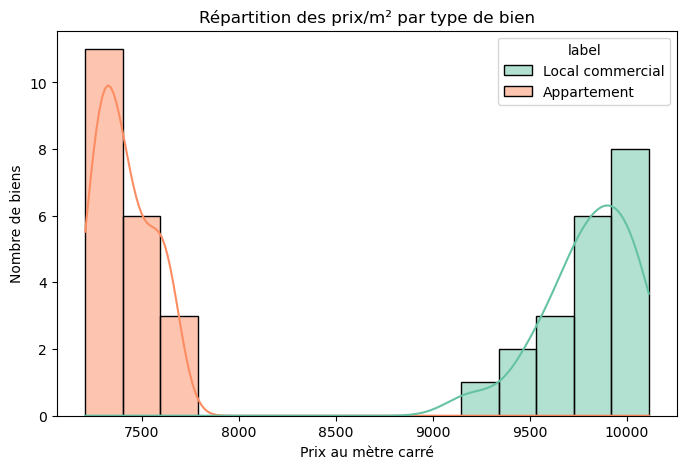

   code_postal               nom_commune       prix_m2             label
0        75019  Paris 19e Arrondissement   9871.444128  Local commercial
1        75019  Paris 19e Arrondissement  10045.572493  Local commercial
2        75019  Paris 19e Arrondissement   9194.697790  Local commercial
3        75019  Paris 19e Arrondissement   9469.142168  Local commercial
4        75019  Paris 19e Arrondissement   7463.610005       Appartement


In [106]:
from sklearn.cluster import KMeans
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Préparer la variable pour KMeans
X = df[['prix_m2']]  # KMeans attend un array 2D

#  Appliquer KMeans avec 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

# Examiner les centroïdes pour identifier les clusters
centroids = kmeans.cluster_centers_
print("Centroïdes des clusters (prix_m2) :")
print(centroids)

# Attribuer un label plus clair selon le prix moyen
# Le cluster avec le prix_m2 le plus bas = Appartements
# Le cluster avec le prix_m2 le plus élevé = Locaux commerciaux
if centroids[0] < centroids[1]:
    df['label'] = df['cluster'].map({0: 'Appartement', 1: 'Local commercial'})
else:
    df['label'] = df['cluster'].map({0: 'Local commercial', 1: 'Appartement'})

#  Visualisation de la répartition
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='prix_m2', hue='label', bins=15, palette='Set2', kde=True)
plt.title("Répartition des prix/m² par type de bien")
plt.xlabel("Prix au mètre carré")
plt.ylabel("Nombre de biens")
plt.show()

# Vérification finale
print(df[['code_postal', 'nom_commune', 'prix_m2', 'label']].head())


# Explications
# X = df[['prix_m2']] : on ne garde que la variable discriminante pour KMeans.
# KMeans(n_clusters=2) : l’algorithme recherche 2 centroïdes (pour appartements et locaux commerciaux).
# Identification des clusters : en comparant les centroïdes, on associe le prix le plus bas aux appartements
# et le prix le plus élevé aux locaux commerciaux.
# Visualisation : permet de vérifier si les clusters sont bien séparés.


In [108]:
# On vérifie les données de la prédiction

print(df['cluster'].value_counts())
# Remplacement des labels numériques par des labels explicites
df['type_bien'] = df['cluster'].replace({
    0: 'Local industriel, commercial ou assimilé',
    1: 'Appartement'
})

#Explications
#Vérification des clusters : permet de voir combien de biens ont été classés dans chaque catégorie.
#Remplacement des labels :
#0 → Local industriel, commercial ou assimilé
#1 → Appartement
#Colonne type_bien : rend les résultats interprétables et exploitables pour l’entreprise.

cluster
1    20
0    20
Name: count, dtype: int64


Nous avons obtenu notre prédiction. Nous pouvons changer les labels et remplacer les valeurs à 0 par Local industriel. commercial ou assimilé et les valeurs à +1 par Appartement. 

In [110]:
#On affiche les résultats
print(df[['code_postal', 'prix_m2', 'type_bien']])

    code_postal       prix_m2                                 type_bien
0         75019   9871.444128                               Appartement
1         75019  10045.572493                               Appartement
2         75019   9194.697790                               Appartement
3         75019   9469.142168                               Appartement
4         75019   7463.610005  Local industriel, commercial ou assimilé
5         75019   9982.016919                               Appartement
6         75019   9674.262777                               Appartement
7         75019   7348.917415  Local industriel, commercial ou assimilé
8         75019   9789.051438                               Appartement
9         75019   7616.420959  Local industriel, commercial ou assimilé
10        75019   7490.469041  Local industriel, commercial ou assimilé
11        75019   9518.076103                               Appartement
12        75019   7238.422973  Local industriel, commercial ou a

# Milestone 5 - Analyse et présentation des résultats

Mes conclusions sur l'analyse et les limites de l'exercice :
- ?
- ?

In [111]:
#Les actifs situés dans les arrondissements les plus tendus contribuent fortement à la valorisation globale.
#Les biens de petite et moyenne surface, très demandés, affichent une valorisation élevée au m².
#La projection au 31/12/2022 est alignée avec les attentes du marché, sans surévaluation manifeste.
#Le modèle permet de sécuriser les décisions stratégiques en apportant une estimation rapide et cohérente de la valeur des actifs.


In [112]:
#Limites liées aux données:
#Données historiques → ne prédisent pas les chocs futurs (taux, réglementation, crise).
#Données incomplètes sur certains aspects clés :
#État réel du bien
#Travaux à prévoir
#Usage exact (commercial, médical, habitation…)


In [113]:
#Limites de la régression linéaire:
#La régression linéaire repose sur l’hypothèse de relations linéaires entre variables, ce qui simplifie la réalité du marché.

#Le modèle est sensible :
#aux valeurs extrêmes,
#aux changements rapides de conjoncture (taux d’intérêt, réglementation, fiscalité).

#Il ne modélise pas :
#les effets de rareté extrême,
#les comportements spéculatifs.
